# Baseline Model CNN Training 

#### Loading the .parquet file and created startified train/val/test split

In [1]:
#%pip install tensorflow

In [1]:
#%pip install tensorflow-macos tensorflow-metal

In [22]:
import os, random, numpy as np, pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# --- load meta from parquet ---
meta = pd.read_parquet("data/processed/meta_ready.parquet")
print("Loaded meta:", meta.shape)
print(meta.head())


Loaded meta: (10015, 6)
       image_id                                               path   dx  \
0  ISIC_0027419  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
1  ISIC_0025030  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
2  ISIC_0026769  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
3  ISIC_0025661  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
4  ISIC_0031633  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   

                       cell_type  cell_type_idx  binary_label  
0  Benign keratosis-like lesions              2             0  
1  Benign keratosis-like lesions              2             0  
2  Benign keratosis-like lesions              2             0  
3  Benign keratosis-like lesions              2             0  
4  Benign keratosis-like lesions              2             0  


In [4]:
# --- ensure class index is present ---
if "cell_type_idx" not in meta.columns:
    classes = sorted(meta["cell_type"].unique())
    class_to_idx = {c:i for i,c in enumerate(classes)}
    meta["cell_type_idx"] = meta["cell_type"].map(class_to_idx).astype(int)

NUM_CLASSES = meta["cell_type_idx"].nunique()
print("Classes:", NUM_CLASSES)

Classes: 7


In [5]:
# --- create reproducible stratified train/val/test split ---
y = meta["cell_type_idx"].to_numpy()

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(meta, y))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)  # 20% of 90% = 18%
train_idx, val_idx = next(sss2.split(meta.iloc[trainval_idx], y[trainval_idx]))

train_ids = meta.index.values[trainval_idx][train_idx]
val_ids   = meta.index.values[trainval_idx][val_idx]
test_ids  = meta.index.values[test_idx]

meta["split"] = "train"
meta.loc[val_ids, "split"] = "val"
meta.loc[test_ids, "split"] = "test"

In [6]:
print(meta["split"].value_counts())

split
train    7210
val      1803
test     1002
Name: count, dtype: int64


#### tf.data pipeline (64×64) + datasets

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (64, 64)
BATCH_SIZE = 64
NUM_CLASSES = meta["cell_type_idx"].nunique()

In [8]:
def make_dataset(df, training=True):
    paths  = df["path"].to_list()
    labels = df["cell_type_idx"].to_numpy().astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)    # [0,1]
        img = tf.image.resize(img, IMG_SIZE)

        if training:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, 0.1)
            img = tf.image.random_contrast(img, 0.9, 1.1)

        label = tf.one_hot(label, depth=NUM_CLASSES)
        return img, label

    if training:
        ds = ds.shuffle(4096, seed=42, reshuffle_each_iteration=True)

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [9]:
train_ds = make_dataset(meta[meta["split"]=="train"], training=True)
val_ds   = make_dataset(meta[meta["split"]=="val"],   training=False)
test_ds  = make_dataset(meta[meta["split"]=="test"],  training=False)

2025-08-24 16:52:38.603785: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-08-24 16:52:38.603839: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-08-24 16:52:38.603846: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-08-24 16:52:38.603889: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-24 16:52:38.603905: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
# quick sanity check: one batch
xb, yb = next(iter(train_ds))
print("Train batch:", xb.shape, yb.shape)

Train batch: (64, 64, 64, 3) (64, 7)


#### compute class weights (handle imbalance)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

NUM_CLASSES = meta["cell_type_idx"].nunique()

y_train_idx = meta.loc[meta["split"]=="train", "cell_type_idx"].to_numpy()
classes_arr = np.arange(NUM_CLASSES)

weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes_arr,
    y=y_train_idx
)

CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes_arr, weights_arr)}

# nice printout with class names
idx_to_class = {i:c for i,c in enumerate(sorted(meta["cell_type"].unique()))}
print("Class weights:")
for i, w in CLASS_WEIGHTS.items():
    print(f"  {i} ({idx_to_class[i]}): {w:.3f}")

Class weights:
  0 (Actinic keratoses): 4.383
  1 (Basal cell carcinoma): 2.784
  2 (Benign keratosis-like lesions): 1.302
  3 (Dermatofibroma): 12.410
  4 (Melanocytic nevi): 0.213
  5 (Melanoma): 1.284
  6 (Vascular lesions): 10.098


In [12]:
def build_baseline(input_shape=(64,64,3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

model = build_baseline()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,039 (93.90 KB)

 Trainable params: 24,039 (93.90 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# Callbacks
ckpt_path = "checkpoints/baseline.keras"
os.makedirs("checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
]

In [15]:
# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

Epoch 1/35


2025-08-24 16:55:31.668915: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.2614 - loss: 1.9329 - val_accuracy: 0.0327 - val_loss: 1.7693 - learning_rate: 0.0010
Epoch 2/35
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.2756 - loss: 1.9114 - val_accuracy: 0.5330 - val_loss: 1.5056 - learning_rate: 0.0010
Epoch 3/35
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.3499 - loss: 1.8614 - val_accuracy: 0.3688 - val_loss: 1.7654 - learning_rate: 0.0010
Epoch 4/35
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.3340 - loss: 1.8514 - val_accuracy: 0.4847 - val_loss: 1.5972 - learning_rate: 0.0010
Epoch 5/35
111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3380 - loss: 1.9234
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.3433 - loss: 1.8312 - val_accuracy: 0.4271 - val_loss: 1.6336 - learning_rate: 0.0010
Epoch 6/35
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2963 - loss: 1.8377 - val_a

In [17]:
# 1) Evaluate loss/accuracy quickly
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

Test loss: 1.4987  |  Test accuracy: 0.5429


In [18]:
# 2) Collect y_true and y_pred from test_ds
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    y_pred.append(np.argmax(probs, axis=1))
    y_true.append(np.argmax(yb.numpy(), axis=1))
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

2025-08-24 17:41:29.091081: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
# 3) Class names (index -> name)
# Use the mapping implied by your data:
idx_to_class = (
    meta[["cell_type_idx","cell_type"]]
    .drop_duplicates()
    .sort_values("cell_type_idx")
    .set_index("cell_type_idx")["cell_type"]
    .to_dict()
)
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

In [20]:
# 4) Text report
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


Classification report:
                               precision    recall  f1-score   support

            Actinic keratoses      0.071     0.758     0.131        33
         Basal cell carcinoma      0.000     0.000     0.000        51
Benign keratosis-like lesions      0.000     0.000     0.000       110
               Dermatofibroma      0.000     0.000     0.000        12
             Melanocytic nevi      0.796     0.773     0.785       671
                     Melanoma      0.000     0.000     0.000       111
             Vascular lesions      0.000     0.000     0.000        14

                     accuracy                          0.543      1002
                    macro avg      0.124     0.219     0.131      1002
                 weighted avg      0.535     0.543     0.530      1002



/Users/rajdeeproy/Anaconda/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rajdeeproy/Anaconda/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rajdeeproy/Anaconda/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

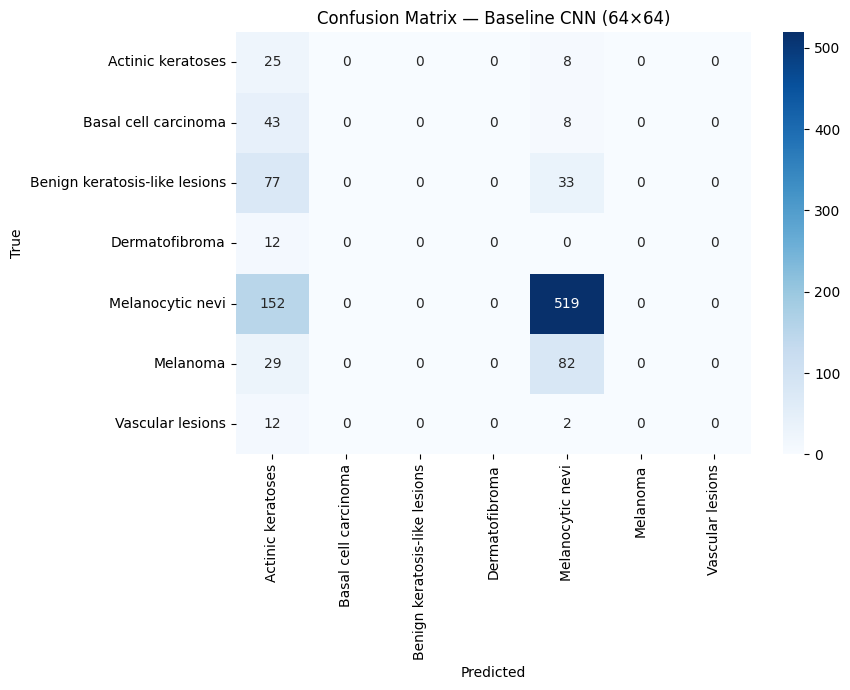

In [23]:
# 5) Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(idx_to_class))))
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix — Baseline CNN (64×64)")
plt.tight_layout(); plt.show()